# Donut 요소(Element) 파인튜닝 노트북

`donut_training_drawings.ipynb`(도면 전체 → JSON)를 **element 크롭 단위**로 바꾼 버전입니다.

- **입력**: YOLO-OBB 가 검출·정렬(rectify)한 element 크롭 (치수 / 공차 / GD&T / 거칠기)
- **정답(학습 타깃)**: 값을 **통짜 텍스트**로 읽는 flat 형식 (`<s_value>8X Ø6.5±0.1</s_value>`). 모델은 **OCR(이미지→텍스트)** 에 집중.
- **구조화는 채점·파이프라인에서** `parse_to_schema` 정규식으로 분해(quantity/nominalValue/upper·lowerLimit 등). 기호(Ø,⊥,±,°)는 **토크나이저에 실제 토큰으로 등록**. 평가는 **field-level F1 + 글자유사도**. 타입은 YOLO 제공.

> **데이터 준비**: `detection/cvat_to_donut.py` 로 CVAT export → `data/elements/{images,labels}` 생성 → 아래 split 셀 실행.
> **커널**: `donut_vml` (검출 YOLO + 인식 Donut 의존성이 모두 설치된 단일 커널 — 커널 전환 불필요).

### 📄 논문 기법 & 본 노트북의 변형 (Khan et al. 2025/2026)

이 노트북은 두 논문의 **Numerical VLM(=element 값 인식)** 방법을 출발점으로, **소량 데이터(~1,975장)에 맞게 변형**했습니다.
> Khan et al., *"A Multi-Stage Hybrid Framework…"* (arXiv:2510.21862) · *"From Drawings to Decisions"* (RCIM 2026).
> 동일 파이프라인(YOLO-det→obb→Donut)으로 element 값 인식에서 **F1 0.935** 보고.

**논문 → 본 노트북 변형**
1. **기호 처리** — 논문은 `"U+XXXX"` ASCII 인코딩. 본 노트북은 **기호(Ø,⊥,±,° …)를 토크나이저 '실제 토큰'으로 등록**(NFKC 안정 글자만, 평문 하이재킹 방지). U+XXXX 의 8글자-코드를 외워 생성하는 부담을 제거. 숫자 `0-9` 도 토큰 등록(미드-스트링 OOV 방지).
2. **학습 타깃** — 논문은 카테고리별 구조화 JSON 을 **직접 생성**. 본 노트북은 **통짜 값(flat)** 만 생성 → 중첩 태그 학습 부담(=깨진 `<s_…>` 태그)을 없애고, **구조 분해는 사후 정규식**(`parse_to_schema`). 타입은 YOLO 제공.
3. **평가지표** — 완전일치(exact) 외 **field-level P/R/F1·hallucination + 값 글자유사도**(부분점수 가시화, exact 0 에 묻힌 진전 노출).

**⚠️ 정확도의 결정적 제약 = 데이터 규모.** 논문은 약 **11,000개** 실 annotation + 수작업 구조화 스키마로 학습.
이 프로젝트는 약 **1,975개** 뿐이라, 위 변형을 적용해도 논문 수준(0.935)에 도달하려면 **실 라벨 데이터 확충이 필수**입니다.

## 파인튜닝 핵심 개념 (요약)

### 전체 흐름

```
    [element 크롭]                    [정답 JSON]
           │                               │
           ▼                               ▼
  ┌─────────────────┐           ┌──────────────────┐
  │  DonutProcessor │           │   json2token()   │
  │  resize / norm  │           │   dict → token   │
  └────────┬────────┘           └────────┬─────────┘
           │ pixel_values                │ target_seq
           └──────────────┬──────────────┘
                          ▼
       ╔══════════════════════════════════════╗
       ║      VisionEncoderDecoderModel       ║
       ║   Swin-T (Encoder) → BART (Decoder)  ║
       ╚═════════════════╤════════════════════╝
                         ▼  logits
                  CrossEntropyLoss → 역전파
```

### 구성 요소 한 줄 정리

| 구성 | 역할 |
|:---|:---|
| **DonutProcessor** | 크롭 이미지 → 리사이즈(`384×384`)·정규화(`[-1,1]`) → `pixel_values` |
| **Swin-T** (encoder) | 이미지 → 시각 특징 |
| **BART** (decoder) | 시각 특징 + 이전 토큰 → 다음 토큰 |
| **json2token / token2json** | dict ↔ `<s_key>값</s_key>` 토큰 상호 변환 |

### 학습 방식 & loss (핵심만)

- **Teacher Forcing**: 학습 땐 이전 *정답* 토큰을 입력으로 줘 안정·빠르게 학습. (추론 땐 이전 *예측* 토큰을 사용)
- **Loss**: 정답 토큰을 맞히는 CrossEntropy. 라벨의 **패딩 위치는 `-100`** 으로 마스킹해 loss 에서 제외.
- **과적합 점검**: `train_loss`는 계속 ↘ 인데 `eval_loss`가 ↗ 로 돌아서면 과적합.
  → `EarlyStoppingCallback` 이 best 지점에서 학습 중단, `load_best_model_at_end` 가 best 가중치 복원.

> 🔹 **환경 점검** — tqdm 위젯 비활성화, PyTorch·Transformers 버전과 GPU(CUDA) 인식 여부 확인.

In [1]:
# ── widget 렌더러 오류 방지 (VS Code Jupyter) ─────────────────────
# tqdm.auto 및 HuggingFace 내부 progress bar가 ipywidget을
# 사용하지 않도록 강제합니다 — 텍스트 모드로 출력됩니다.
import os
os.environ['TQDM_NOTEBOOK'] = 'false'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'  # tokenizer 경고 억제

# ── Step 0: 환경 확인 ──────────────────────────────────────────────
# 학습에 필요한 라이브러리 버전과 GPU 상태를 먼저 점검합니다.
# CUDA가 False이면 GPU를 인식하지 못한 것 — 드라이버/환경을 확인하세요.
import torch
import transformers
import platform

print(f"Python     : {platform.python_version()}")
print(f"PyTorch    : {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"CUDA 사용   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


/home/jhkim/anaconda3/envs/donut_vml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python     : 3.10.20
PyTorch    : 2.11.0+cu128
Transformers: 5.12.1
CUDA 사용   : True
GPU        : NVIDIA GeForce RTX 5090
VRAM       : 33.7 GB


> 🔹 필수 패키지(datasets·sentencepiece) 설치 여부 확인 후 없으면 자동 설치.

In [2]:
# ── 필수 패키지 설치 확인 ─────────────────────────────────────────
# 이미 설치된 경우 무시됩니다 — 매번 실행해도 안전합니다.
# datasets  : HuggingFace 데이터셋 다운로드 라이브러리
# sentencepiece : Donut 토크나이저가 내부적으로 사용하는 형태소 분석기
import importlib, subprocess, sys

required = {"datasets": "datasets", "sentencepiece": "sentencepiece"}
missing  = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]

if missing:
    print(f"설치 중: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing, "-q"])
    print("설치 완료 — 커널을 재시작하지 않아도 됩니다.")
else:
    print("모든 패키지 설치 확인 ✓")


모든 패키지 설치 확인 ✓


> 🔹 학습 전반에 쓰는 공통 라이브러리(json·torch·PIL·Donut 클래스 등) import.

In [3]:
# ── 공통 Import ───────────────────────────────────────────────────
import json       # JSON 파일 읽기/쓰기
import os         # 파일 경로, 디렉터리 생성
import random     # 데이터셋 셔플 및 시드 고정
import re         # 정규표현식 (토큰 파싱에 사용)
import shutil
from pathlib import Path  # 운영체제 독립적인 파일 경로 처리

import numpy as np         # 수치 연산 및 시드 고정
from PIL import Image      # 이미지 파일 열기/변환
# tqdm.auto는 VS Code Jupyter에서 ipywidget 오류를 유발하므로 tqdm 직접 사용
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader  # 커스텀 데이터셋 클래스

from transformers import (
    DonutProcessor,              # 이미지 전처리 + 텍스트 토크나이저 통합 유틸리티
    VisionEncoderDecoderModel,   # 인코더(Swin-T) + 디코더(BART) 통합 모델
    Seq2SeqTrainer,              # Seq2Seq 학습 자동화 (forward/backward/저장)
    Seq2SeqTrainingArguments,    # 학습 하이퍼파라미터 설정
)

# ── matplotlib 전역 스타일 설정 ────────────────────────────────────
# 흰 배경에서도 텍스트/축/선이 선명하게 보이도록 전역 적용
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    "figure.facecolor": "white",   # 그림 배경 흰색
    "axes.facecolor":   "white",   # 축 영역 배경 흰색
    "savefig.facecolor":"white",   # 저장 시에도 흰 배경
    "text.color":       "black",   # 모든 텍스트 검정
    "axes.labelcolor":  "black",   # 축 레이블 검정
    "xtick.color":      "black",   # x축 눈금 검정
    "ytick.color":      "black",   # y축 눈금 검정
    "axes.edgecolor":   "black",   # 축 테두리 검정
})

# ── 한글 폰트 설정 (plot 한글 깨짐 / Glyph 경고 방지) ──────────────
# 시스템의 Noto Sans CJK(KR 포함)를 등록해 matplotlib 기본 폰트로 사용
from matplotlib import font_manager as _fm
_ko_font = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
try:
    _fm.fontManager.addfont(_ko_font)
    matplotlib.rcParams["font.family"] = _fm.FontProperties(fname=_ko_font).get_name()
except Exception as _e:
    print("한글 폰트 등록 실패(영문만 표시됨):", _e)
matplotlib.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

print("Import 완료 ✓  (한글 폰트:", matplotlib.rcParams["font.family"], ")")


한글 폰트 등록 실패(영문만 표시됨): [Errno 2] No such file or directory: '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
Import 완료 ✓  (한글 폰트: ['sans-serif'] )


> 🔹 **공통 헬퍼 정의** — flat 토큰 변환(`json2token`/`token2json`) · 카테고리별 구조화 파서(`parse_to_schema`, 채점·파이프라인용) · field-level F1·hallucination·값 글자유사도.

In [4]:
# ── 공통: 스키마·토큰·문자 헬퍼 ──
# [A] 기호(Ø,⊥,±,° …)는 Step 2 에서 토크나이저에 '실제 토큰'으로 등록 → U+XXXX 인코딩 폐기(항등).
# [B] 학습은 통짜 값 텍스트(flat), 채점은 parse_to_schema 로 양쪽을 구조화(부분점수 가시화).
import re
from difflib import SequenceMatcher

def encode_symbols(s): return str(s)          # 항등(기호는 토큰 등록으로 처리)
def decode_symbols(s): return str(s)
def _walk(o, fn):
    if isinstance(o, dict): return {k: _walk(v, fn) for k, v in o.items()}
    if isinstance(o, list): return [_walk(v, fn) for v in o]
    return fn(str(o))
def encode_tree(o): return _walk(o, encode_symbols)
def decode_tree(o): return _walk(o, decode_symbols)

def json2token(obj, sort_keys=True):
    """dict/list → Donut XML 토큰. {"a":"1"} → <s_a>1</s_a>"""
    if isinstance(obj, dict):
        out = ""
        for k in (sorted(obj, reverse=True) if sort_keys else obj):
            out += f"<s_{k}>" + json2token(obj[k], sort_keys) + f"</s_{k}>"
        return out
    if isinstance(obj, list):
        return "<sep/>".join(json2token(v, sort_keys) for v in obj)
    return str(obj)

def token2json(tokens):
    """<s_k>v</s_k> → dict (json2token 역변환)."""
    out = {}
    while tokens:
        st = re.search(r"<s_(.+?)>", tokens)
        if not st: break
        key = st.group(1); end = f"</s_{key}>"; ep = tokens.find(end, st.end())
        if ep == -1: break
        val = tokens[st.end():ep]
        out[key] = token2json(val) if "<s_" in val else val.strip()
        tokens = tokens[ep+len(end):]
    return out if out else tokens.strip()

# ── 카테고리별 스키마 파서: flat 값 → 구조화 dict (채점·파이프라인용) ──
def _parse_measure(v):
    o = {}; s = v.strip()
    m = re.match(r"^\s*(\d+)\s*[xX×*]\s*(.+)$", s)            # 수량  N× / NX
    if m: o["quantity"] = m.group(1); s = m.group(2).strip()
    m = re.search(r"±\s*([0-9.,]+)", s)                       # 대칭 공차 ±t
    if m:
        o["upperLimit"] = "+" + m.group(1); o["lowerLimit"] = "-" + m.group(1)
        s = (s[:m.start()] + s[m.end():]).strip()
    else:
        m = re.search(r"\+\s*([0-9.,]+)\s*[-/]\s*([0-9.,]+)", s)   # 비대칭 +a -b
        if m:
            o["upperLimit"] = "+" + m.group(1); o["lowerLimit"] = "-" + m.group(2)
            s = s[:m.start()].strip()
    if s: o["nominalValue"] = s
    return o or {"nominalValue": v.strip()}

def _parse_gdt(v):
    o = {}; s = v.strip()
    m = re.match(r"^([^0-9A-Za-z\s.]+)\s*(.*)$", s)           # 선두 기호 = 기하특성
    if m and m.group(1).strip():
        o["geometricCharacteristic"] = m.group(1).strip(); s = m.group(2).strip()
    m = re.search(r"((?:[A-Z](?:\s|$))+)$", s)                # 후미 데이텀 문자들
    if m:
        dats = re.findall(r"[A-Z]", m.group(1))
        if dats: o["datumReference"] = dats; s = s[:m.start()].strip()
    if s: o["tolerance"] = s
    return o or {"tolerance": v.strip()}

def _norm_value(s):
    """디코드 아티팩트 공백 정리: 소수점·부호·기호 주변 공백 제거(데이텀 글자 사이 공백은 보존)."""
    s = re.sub(r"\s*\.\s*", ".", str(s))                 # "0 .1" → "0.1"
    s = re.sub(r"([+\-±°Ø∅⌀⊥∡∥])\s+", r"\1", s)         # 기호/부호 바로 뒤 공백 제거
    s = re.sub(r"\s+°", "°", s)                          # 도(°) 앞 공백
    return s.strip()

def parse_to_schema(cls, value):
    """{class: value} 의 value → 카테고리별 구조화 dict (채점·파이프라인용)."""
    v = str(value)
    if cls in ("Dimension", "Measure", "Measures", "Radii", "Radius"): return _parse_measure(v)
    if cls in ("GD&T_FCF", "GD&T", "GDT"):                             return _parse_gdt(v)
    if cls == "Surface_Roughness":                                     return {"roughness": v.strip()}
    if cls == "Datum":                                                 return {"datum": v.strip()}
    return {"value": v.strip()}                                        # Hole_Callout 등

# ── 평가: field-level P/R/F1 + hallucination, + 값 글자유사도 ──
def _flatten(d, pre=""):
    it = {}
    if isinstance(d, dict):
        for k, v in d.items(): it.update(_flatten(v, f"{pre}/{k}"))
    elif isinstance(d, list):
        for i, v in enumerate(d): it.update(_flatten(v, f"{pre}[{i}]"))
    else: it[pre] = re.sub(r"\s+", "", str(d))
    return it

def field_prf1(pred, gt):
    pf, gf = _flatten(pred), _flatten(gt)
    tp = sum(1 for k, v in gf.items() if pf.get(k) == v)
    P = tp / max(1, len(pf)); R = tp / max(1, len(gf)); F = 2*P*R / max(1e-9, P+R)
    return P, R, F, (1 - P)

def value_charsim(a, b):    # 통짜 값 글자유사도(진전 가시화: exact 0 에 묻힌 부분정답)
    na = re.sub(r"\s+", "", str(a)); nb = re.sub(r"\s+", "", str(b))
    return SequenceMatcher(None, na, nb).ratio()

print("스키마/토큰/문자 헬퍼 정의 완료 ✓ (flat 학습 + 구조화 채점)")


스키마/토큰/문자 헬퍼 정의 완료 ✓ (flat 학습 + 구조화 채점)


## Step 1 – 설정 (Configuration)

모든 하이퍼파라미터를 딕셔너리로 관리합니다.  
`dataset_name`을 `None`으로 바꾸고 `local_train_dir` / `local_val_dir`을 지정하면 커스텀 데이터셋을 사용할 수 있습니다.

> 🔹 **전역 설정(CFG) 정의** — 모델·데이터·학습 하이퍼파라미터와 구조화 스키마 방식 명시.

In [5]:
# ── Step 1: 설정 (Element Donut 파인튜닝용 · flat 값 학습 + 사후 구조화) ───
# YOLO 가 검출·분류한 element 크롭을 입력으로, 그 '값(value)'만 읽도록 Donut 을 파인튜닝.
#
# 설계: 타입은 YOLO 가 제공 → Donut 은 '통짜 값 텍스트'만 생성(OCR 집중).
#   타깃 = task_prompt(<s_element>) + <s_value>raw</s_value> + eos
#     예) "8X Ø6.5±0.1" → <s_value>8X Ø6.5±0.1</s_value>
#   기호는 토크나이저에 실제 토큰으로 등록(U+XXXX 없음). 구조 분해(quantity/nominalValue/…)·
#   평가(field-F1 + 글자유사도)는 parse_to_schema 로 사후 처리.
CFG = {
    "model": {
        "pretrained_model_name": "naver-clova-ix/donut-base",
        "max_length": 128,        # element 값은 짧음
        "image_size": [384, 384], # element 크롭은 작음 → 작은 해상도로 충분(메모리·속도 이득)
    },
    "data": {
        "dataset_name": None,                       # 로컬 모드
        "task_prompt": "<s_element>",
        "local_train_dir": "../data/processed_elements/train",
        "local_val_dir":   "../data/processed_elements/val",
        "augment":  False,   # (나) on-the-fly 증강 — 베이스라인 False, 개선 런에서 True
        "synth_n":  0,       # (가) 합성 생성 장수 — 0=생성 안 함 (예: 8000)
        "synth_dir": None,   # (가) 합성 출력/병합 경로 (예: "../data/elements_synth")
    },
    "training": {
        "output_dir": "../checkpoints_elements",
        "num_epochs": 60,        # 상한값 — early_stopping_patience 로 더 일찍 종료됨
        "batch_size": 8,          # 작은 이미지 → 배치 확대 가능 (VRAM 부족 시 낮추기)
        "gradient_accumulation_steps": 2,
        "learning_rate": 3e-5,
        "warmup_steps": 50,
        "weight_decay": 0.01,
        "bf16": True,             # ★ fp16 은 Donut 에서 불안정 → bf16 고정
        "fp16": False,
        "save_steps": 50,
        "eval_steps": 50,
        "early_stopping_patience": 5,  # eval_loss 5회 연속 개선 없으면 조기 종료
        "logging_steps": 10,
        "dataloader_num_workers": 4,
        "seed": 42,
    },
    "wandb": {"enabled": False, "project": "donut-elements", "run_name": None},
}
print("Config (element) loaded ✓")
print(f"  태스크   : {CFG['data']['task_prompt']}")
print(f"  학습 출력: {CFG['training']['output_dir']}")

Config (element) loaded ✓
  태스크   : <s_element>
  학습 출력: ../checkpoints_elements


> 🔹 재현성을 위한 난수 시드 고정(Python·NumPy·PyTorch·CUDA).

In [6]:
# ── 재현성을 위한 시드 고정 ────────────────────────────────────────
# 동일한 시드를 설정하면 같은 코드를 다시 실행해도 동일한 결과가 나옵니다.
# Python / NumPy / PyTorch / CUDA 각각의 난수 생성기를 모두 고정해야 합니다.
def set_seed(seed: int):
    random.seed(seed)        # Python 기본 random 모듈
    np.random.seed(seed)     # NumPy 난수
    torch.manual_seed(seed)  # CPU 연산 난수
    torch.cuda.manual_seed_all(seed)  # GPU 연산 난수 (멀티GPU 포함)

set_seed(CFG["training"]["seed"])
print(f"Seed = {CFG['training']['seed']} 고정 완료")


Seed = 42 고정 완료


## Element 데이터셋 준비 (train/val 분리)

`data/elements/{images,labels}` (crop PNG + `{"<type>":"<value>"}` JSON) 을
`data/processed_elements/{train,val}` 로 분리합니다. 라벨은 `detection/cvat_to_donut.py` 로 CVAT export 에서 생성.

> 🔹 element 크롭+라벨 쌍을 train/val 로 분리해 processed_elements 디렉터리에 저장.

In [7]:
# ── element 데이터 train/val 분리 ─────────────────
import shutil, random
from pathlib import Path

SRC = Path("../data/elements")
OUT = Path("../data/processed_elements")
VAL_RATIO, SEED = 0.1, CFG["training"]["seed"]

img_dir, lbl_dir = SRC / "images", SRC / "labels"
stems = sorted(p.stem for p in img_dir.glob("*.png")
               if (lbl_dir / (p.stem + ".json")).exists())
assert stems, f"{SRC} 에 crop+label 쌍이 없습니다 — cvat_to_donut.py 를 먼저 실행하세요"
random.Random(SEED).shuffle(stems)
n_val = max(1, int(len(stems) * VAL_RATIO))
splits = {"val": stems[:n_val], "train": stems[n_val:]}

for split, names in splits.items():
    for sub in ("images", "labels"):
        (OUT / split / sub).mkdir(parents=True, exist_ok=True)
    for st in names:
        shutil.copy(img_dir / f"{st}.png",  OUT / split / "images" / f"{st}.png")
        shutil.copy(lbl_dir / f"{st}.json", OUT / split / "labels" / f"{st}.json")
print({k: len(v) for k, v in splits.items()})

{'val': 197, 'train': 1778}


### (라) 라벨 노이즈 점검·정제  *(기본 report-only)*
`�`(U+FFFD)·제어문자·variation-selector 등 **깨진 라벨**을 스캔합니다. 실제 수정은 `APPLY=True` 로.

In [ ]:
# (라) 라벨 노이즈 스캔/정제 — processed_elements/{train,val}/labels
import json, glob, unicodedata, re
APPLY = False   # True 로 바꾸면 정제본을 덮어씀(되돌리려면 split 셀 재실행)
def _bad(ch):
    return ch in "\ufffd\ufe0f" or unicodedata.category(ch) in ("Cc", "Cf", "Co", "Cn")
tot = hit = 0; samples = []
for d in ("train", "val"):
    for f in glob.glob(f"../data/processed_elements/{d}/labels/*.json"):
        g = json.load(open(f, encoding="utf-8")); k = next(iter(g)); v = str(g[k]); tot += 1
        bad = [c for c in v if _bad(c)]
        if bad:
            hit += 1
            if len(samples) < 12: samples.append((k, v))
            if APPLY:
                cleaned = re.sub(r"\s+", " ", "".join(c for c in v if not _bad(c))).strip()
                json.dump({k: cleaned}, open(f, "w", encoding="utf-8"), ensure_ascii=False)
print(f"노이즈 라벨: {hit}/{tot}" + ("  (정제 적용됨)" if APPLY else "  (report-only; APPLY=True 로 정제)"))
for k, v in samples: print(f"  [{k}] {v!r}")


### (가) 합성 데이터 생성  *(기본 OFF)*
`CFG.data.synth_n>0` + `synth_dir` 설정 시 `detection/synth_elements.py` 로 공짜 라벨 크롭을 생성합니다.
생성 후 아래 `build_datasets` 가 **train 에만** 자동 병합(val 은 실데이터 유지).

In [ ]:
# (가) 합성 데이터 생성 — CFG.data.synth_n > 0 일 때만
import subprocess, sys
_sn = CFG["data"].get("synth_n", 0); _sd = CFG["data"].get("synth_dir")
if _sn and _sd:
    print(f"합성 {_sn}장 생성 → {_sd}")
    subprocess.run([sys.executable, "detection/synth_elements.py",
                    "--n", str(_sn), "--out", _sd, "--seed", str(CFG["training"]["seed"])], check=True)
    print("합성 생성 완료 — build_datasets 가 train 에 병합합니다.")
else:
    print("합성 생성 건너뜀 (CFG.data.synth_n=0). 켜려면 CFG 에서 synth_n>0 + synth_dir 설정 후 재실행.")


## Step 2 – 모델 & 프로세서 로드

- **DonutProcessor**: 이미지 전처리(resize/normalize) + 토크나이저
- **VisionEncoderDecoderModel**: 인코더(Swin-T) + 디코더(BART)

task token `<s_element>` 와 **라벨의 모든 타입 토큰**(`<s_dimension>` 등)을 토크나이저에 추가하고 임베딩을 확장합니다.
타입 토큰은 **train+val 라벨에서 모아 등록** — 희소 타입(예: roughness)이 한쪽 split 에만 있어도 누락되지 않습니다.

> 🔹 **Donut 모델·프로세서 빌드 함수 정의** — 이미지 크기·토큰·디코더 설정.

In [8]:
# ── Step 2: 모델 & 프로세서 빌드 (flat 스키마 + 기호 토큰 등록) ──
def build_model_and_processor(cfg):
    model_cfg  = cfg["model"]; name = model_cfg["pretrained_model_name"]
    image_size = model_cfg["image_size"]; max_length = model_cfg["max_length"]
    processor = DonutProcessor.from_pretrained(name, backend="pil")
    model     = VisionEncoderDecoderModel.from_pretrained(name)
    processor.image_processor.size = {"height": image_size[0], "width": image_size[1]}
    processor.image_processor.do_align_long_axis = False
    model.config.encoder.image_size = image_size
    model.config.decoder.max_length = max_length

    task_prompt = cfg["data"]["task_prompt"]
    # [B] flat 스키마: 모델은 통짜 값 한 개만 생성 (<s_value>…</s_value>). 구조 분해는 평가/파이프라인에서 정규식.
    special = [task_prompt, "<sep/>", "<s_value>", "</s_value>"]
    num_added = processor.tokenizer.add_special_tokens({"additional_special_tokens": special})

    # [A] 값 글자 보강: 도면/GD&T 기호를 '일반' 토큰으로 등록(U+XXXX 폐기) + 숫자 0-9(미드-스트링 OOV 방지).
    import unicodedata
    val_chars = set()
    for _sd in (cfg["data"]["local_train_dir"], cfg["data"]["local_val_dir"]):
        for _f in (Path(_sd) / "labels").glob("*.json"):
            for _v in json.load(open(_f, encoding="utf-8")).values():
                val_chars.update(str(_v))
    # 비-ASCII 중 NFKC 안정(자기자신=정규화결과)인 글자만 — 평문 하이재킹(Ⓜ→M 등) 방지
    syms = sorted(c for c in val_chars if ord(c) > 127 and unicodedata.normalize("NFKC", c) == c)
    n_sym   = processor.tokenizer.add_tokens(syms)
    n_digit = processor.tokenizer.add_tokens(list("0123456789"))

    if num_added or n_sym or n_digit:
        model.decoder.resize_token_embeddings(len(processor.tokenizer), mean_resizing=False)
    print(f"토큰 추가: 구조 {num_added}개 + 기호 {n_sym}개 [{''.join(syms)}] + 숫자 {n_digit}개")

    # OOV 진단: 라벨 값의 <unk> 포함 비율 (0% 에 수렴해야 함)
    unk = processor.tokenizer.unk_token_id; tot = bad = 0
    for _sd in (cfg["data"]["local_train_dir"], cfg["data"]["local_val_dir"]):
        for _f in (Path(_sd) / "labels").glob("*.json"):
            for _v in json.load(open(_f, encoding="utf-8")).values():
                tot += 1
                if unk in processor.tokenizer(str(_v), add_special_tokens=False).input_ids: bad += 1
    print(f"값 <unk> 포함: {bad}/{tot} ({bad/max(1,tot)*100:.2f}%)")

    model.config.pad_token_id           = processor.tokenizer.pad_token_id
    model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(task_prompt)
    return model, processor


model, processor = build_model_and_processor(CFG)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)
enc_p = sum(p.numel() for p in model.encoder.parameters()) / 1e6
dec_p = sum(p.numel() for p in model.decoder.parameters()) / 1e6
print(f"디바이스 {device} | 인코더 {enc_p:.1f}M (Swin) / 디코더 {dec_p:.1f}M (BART)")
print(f"Decoder start token: {processor.tokenizer.convert_ids_to_tokens([model.config.decoder_start_token_id])}")


Loading weights: 100%|██████████| 484/484 [00:00<00:00, 68735.80it/s]


토큰 추가: 구조 4개 + 기호 31개 [°±·×ØàΔТ—→↓−√∞∠∡∥⊘⊙⊥⊿⌒⏥─━△◎⟂⟵️�] + 숫자 10개
값 <unk> 포함: 0/1975 (0.00%)
디바이스 cuda | 인코더 74.2M (Swin) / 디코더 127.7M (BART)
Decoder start token: ['<s_element>']


## Step 3 – 데이터셋 구성 & 시각화

### DonutDataset 동작 원리

| 입력 | 처리 | 출력 |
|------|------|------|
| PIL Image | DonutProcessor → pixel_values | `(C, H, W)` Tensor |
| JSON ground truth | Tokenizer → teacher-forcing label | `(max_length,)` Token IDs |

**패딩 토큰 → -100**: CrossEntropyLoss는 `-100`으로 표시된 위치를 자동으로 무시합니다 (패딩 위치에서 loss 계산 안 함).

### 이 노트북의 데이터셋

로컬 element 크롭만 사용합니다 (`CFG.data.dataset_name = None`):

- `local_train_dir` / `local_val_dir` = `data/processed_elements/{train,val}`
- 라벨 = element 1개당 `{"<type>": "<value>"}` (예: `{"dimension": "Ø65"}`) — **학습 타깃은 값 통짜 텍스트(flat, `<s_value>…</s_value>`)**. 구조 분해(`parse_to_schema`)는 **채점·파이프라인에서만** 사용.

> `dataset_name` 에 HuggingFace ID(예: `naver-clova-ix/cord-v2`)와 그에 맞는 `task_prompt` 를 넣으면
> 공개 데이터셋으로도 학습할 수 있지만, 이 노트북의 목적은 **도면 element 인식**입니다.

> 🔹 **DonutDataset 클래스 정의** — 구조화 dict 를 task 프롬프트+토큰 타깃으로 변환.

In [9]:
# ── Step 3a: DonutDataset 정의 (flat 값 타깃) ──────────────
# [B] 타깃 = task_prompt + <s_value>raw</s_value> + eos.
#   모델은 '통짜 값 텍스트'만 학습(OCR 집중). 구조 분해(quantity/nominalValue/…)는 평가/파이프라인에서 정규식.
#   기호는 [A] 에서 실제 토큰으로 등록되어 raw 그대로 사용(U+XXXX 인코딩 없음).
class DonutDataset(Dataset):
    def __init__(self, dataset_or_root, processor, max_length: int, task_prompt: str, augment: bool = False):
        self.processor = processor; self.max_length = max_length; self.task_prompt = task_prompt
        self.augment = augment
        self.samples = self._load_local(Path(dataset_or_root))

    def _load_local(self, root: Path):
        exts = {".png", ".jpg", ".jpeg", ".tiff", ".bmp"}; out = []
        for ip in sorted((root / "images").glob("*")):
            if ip.suffix.lower() in exts:
                lp = root / "labels" / (ip.stem + ".json")
                if lp.exists(): out.append((ip, lp))
        return out

    def __len__(self): return len(self.samples)

    def _aug(self, img):   # (나) 약한 증강 — 작은 데이터 과적합 완화
        import random
        from PIL import ImageEnhance
        if random.random() < 0.5: img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
        if random.random() < 0.5: img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
        if random.random() < 0.3: img = img.rotate(random.uniform(-3, 3), expand=False, fillcolor=(255, 255, 255))
        return img

    def __getitem__(self, idx):
        ip, lp = self.samples[idx]
        image = Image.open(ip).convert("RGB")
        if self.augment: image = self._aug(image)
        gt = json.load(open(lp, encoding="utf-8"))
        raw = str(next(iter(gt.values())))                     # 통짜 값 텍스트
        target_seq = (self.task_prompt
                      + json2token({"value": raw})             # <s_value>raw</s_value>
                      + self.processor.tokenizer.eos_token)
        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(target_seq, add_special_tokens=False,
            max_length=self.max_length, padding="max_length", truncation=True,
            return_tensors="pt").input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels, "target_sequence": target_seq}

print("DonutDataset(flat 값 타깃) 정의 완료 ✓")


DonutDataset(flat 값 타깃) 정의 완료 ✓


> 🔹 설정에 따라 로컬/HuggingFace 데이터셋을 로드해 train·val Dataset 생성.

In [10]:
# ── Step 3b: 데이터셋 로드 ────────────────────────────────────────
# CFG 설정에 따라 HuggingFace 또는 로컬 디렉터리에서 데이터를 로드합니다.
# dataset_name이 지정되면 인터넷에서 자동 다운로드하고,
# None이면 local_train_dir / local_val_dir 경로를 사용합니다.
def build_datasets(cfg, processor):
    data_cfg   = cfg["data"]
    max_length = cfg["model"]["max_length"]
    prompt     = data_cfg["task_prompt"]

    if data_cfg.get("dataset_name"):          # HuggingFace 데이터셋
        from datasets import load_dataset
        # load_dataset은 처음 실행 시 다운로드 후 로컬에 캐시합니다
        raw      = load_dataset(data_cfg["dataset_name"])
        train_ds = DonutDataset(raw[data_cfg["train_split"]], processor, max_length, prompt)
        val_ds   = DonutDataset(raw[data_cfg["val_split"]],   processor, max_length, prompt)
    else:                                      # 로컬 디렉터리
        train_ds = DonutDataset(data_cfg["local_train_dir"], processor, max_length, prompt,
                                augment=data_cfg.get("augment", False))
        val_ds   = DonutDataset(data_cfg["local_val_dir"],   processor, max_length, prompt)

    # (가) 합성 데이터가 있으면 TRAIN 에만 병합 (val 은 실데이터 유지)
    sdir = data_cfg.get("synth_dir")
    if sdir and (Path(sdir) / "images").exists():
        from torch.utils.data import ConcatDataset
        synth_ds = DonutDataset(sdir, processor, max_length, prompt, augment=data_cfg.get("augment", False))
        if len(synth_ds):
            train_ds = ConcatDataset([train_ds, synth_ds])
            print(f"  + 합성 {len(synth_ds):,} 장 병합 → train {len(train_ds):,}")

    return train_ds, val_ds


train_ds, val_ds = build_datasets(CFG, processor)
print(f"Train 샘플 수: {len(train_ds):,}")
print(f"Val   샘플 수: {len(val_ds):,}")


Train 샘플 수: 1,778
Val   샘플 수: 197


> 🔹 학습 샘플 3개를 이미지+정답 라벨과 함께 시각화해 데이터 로드 검증.

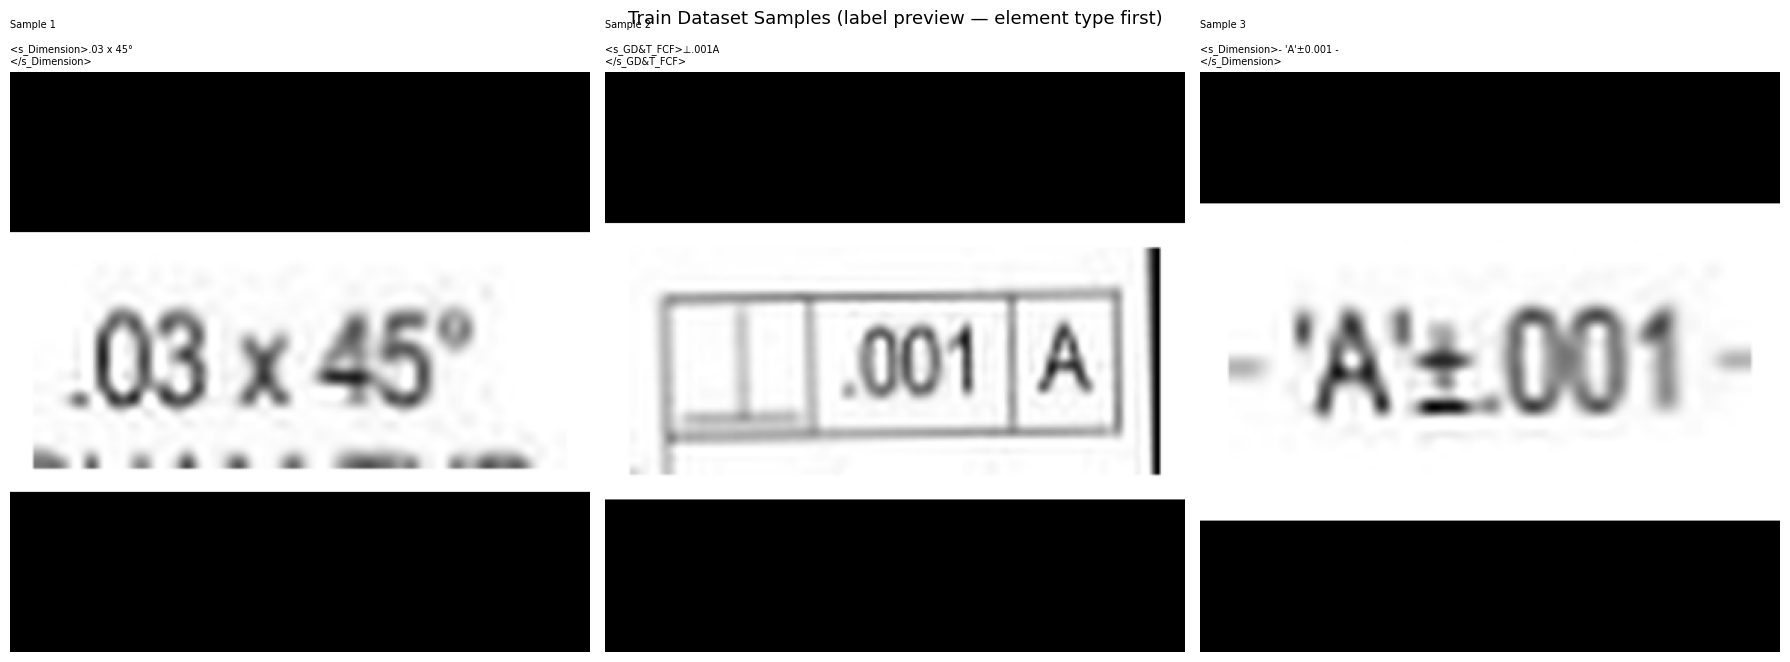


샘플 1 — 유효 토큰 수: 14 / 128
  (나머지 114개는 패딩 — loss 계산 제외)


In [11]:
# ── Step 3c: 샘플 시각화 ──────────────────────────────────────────
# 학습 데이터가 올바르게 로드됐는지 눈으로 확인합니다.
# 라벨(정답)을 element 타입(dimension/tolerance/gdt/roughness) 우선 순서로 표시합니다.
# (target_sequence는 json2token이 키를 역순 정렬해 샘플마다 앞 필드가 달라지므로,
#  미리보기는 아래 PREVIEW_ORDER로 다시 정렬해 일관되게 보여줍니다.)
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

PREVIEW_ORDER = ["dimension", "tolerance", "gdt", "roughness"]
PREVIEW_CHARS = 220   # 표시할 토큰 문자 수 (이전 80 → 220)

def preview_seq(label: dict) -> str:
    # PREVIEW_ORDER에 있는 키를 먼저, 그 외 키는 뒤에 붙여 토큰화
    keys = [k for k in PREVIEW_ORDER if k in label] + \
           [k for k in label if k not in PREVIEW_ORDER]
    s = "".join(f"<s_{k}>" + json2token(label[k]) + f"</s_{k}>" for k in keys)
    return s[:PREVIEW_CHARS]

for idx, ax in enumerate(axes):
    i = idx + 1  # 1,2,3번째 샘플을 출력
    sample = train_ds[i]

    # pixel_values는 [-1, 1]로 정규화되어 있으므로 [0, 1]로 되돌려 표시
    img_tensor = sample["pixel_values"]
    img_np     = (img_tensor.permute(1, 2, 0).numpy() + 1) / 2  # [-1,1] → [0,1]
    img_np     = img_np.clip(0, 1)
    ax.imshow(img_np)
    ax.axis("off")

    # 로컬 모드: 라벨 dict를 파일에서 직접 읽어 핵심 필드 우선으로 미리보기 구성
    if getattr(train_ds, "mode", "local") == "local":
        label    = json.load(open(train_ds.samples[i][1], encoding="utf-8"))
        gt_short = preview_seq(label)
    else:
        gt_short = sample["target_sequence"][:PREVIEW_CHARS]
    # "<" 앞에 줄바꿈을 넣어 토큰 구조를 읽기 쉽게
    gt_short = gt_short.replace("<", "\n<")
    ax.set_title(f"Sample {i}\n{gt_short}", fontsize=7, loc="left")

plt.suptitle("Train Dataset Samples (label preview — element type first)", fontsize=13)
plt.tight_layout()
plt.show()

# 유효 토큰 수 확인: -100이 아닌 위치 = 실제 정답 토큰 수
# max_length 중 실제 정보가 몇 토큰인지 파악할 수 있습니다
valid_tokens = (train_ds[1]["labels"] != -100).sum().item()
print(f"\n샘플 1 — 유효 토큰 수: {valid_tokens} / {CFG['model']['max_length']}")
print(f"  (나머지 {CFG['model']['max_length'] - valid_tokens}개는 패딩 — loss 계산 제외)")


## Step 4 – 학습 (Training)

`Seq2SeqTrainer` 로 학습합니다. 핵심 설정:

| 옵션 | 설명 |
|:---|:---|
| `bf16=True` | Donut 권장 혼합정밀도 (fp16 은 수치 불안정) |
| `gradient_accumulation_steps` | 실효 배치를 키우면서 VRAM 절감 |
| `predict_with_generate=False` | 평가는 `eval_loss` 만 측정(생성 생략 → 빠름). Leaf-Match 점수는 **Step 5b**에서 별도 계산 |
| `load_best_model_at_end=True` | 종료 후 `eval_loss` 최저 체크포인트 자동 복원 |
| `EarlyStoppingCallback(patience=5)` | `eval_loss` 가 5회 평가 연속 개선 없으면 조기 종료 (과적합 방지) |

> 🔹 Seq2SeqTrainer 로 Donut 파인튜닝 실행(학습·검증·체크포인트 저장·조기 종료).

In [12]:
# ── Step 4: 학습 실행 ─────────────────────────────────────────────
# Seq2SeqTrainer가 다음을 자동으로 처리합니다:
#   - 매 스텝: forward → loss 계산 → backward → 가중치 업데이트
#   - 매 eval_steps: 검증셋으로 eval_loss 측정
#   - 매 save_steps: 체크포인트 저장
#   - 학습 완료 후: eval_loss 최소 체크포인트 자동 복원
if CFG["wandb"]["enabled"]:
    import wandb
    wandb.init(
        project=CFG["wandb"]["project"],
        name=CFG["wandb"]["run_name"],
        config=CFG,
    )

from transformers import EarlyStoppingCallback   # 조기 종료 콜백

tcfg = CFG["training"]

training_args = Seq2SeqTrainingArguments(
    output_dir                  = tcfg["output_dir"],
    num_train_epochs            = tcfg["num_epochs"],
    per_device_train_batch_size = tcfg["batch_size"],
    per_device_eval_batch_size  = tcfg["batch_size"],
    gradient_accumulation_steps = tcfg["gradient_accumulation_steps"],
    learning_rate               = tcfg["learning_rate"],
    warmup_steps                = tcfg["warmup_steps"],   # 초반 lr 웜업 구간
    weight_decay                = tcfg["weight_decay"],   # 과적합 방지 정규화
    bf16                        = tcfg.get("bf16", True),  # bf16 혼합정밀도 (Donut 안정적)
    fp16                        = tcfg.get("fp16", False),
    save_steps                  = tcfg["save_steps"],
    eval_steps                  = tcfg["eval_steps"],
    logging_steps               = tcfg["logging_steps"],
    save_total_limit            = 3,          # 가장 최신 체크포인트 3개만 보관
    eval_strategy               = "steps",    # transformers ≥4.45 변경된 파라미터명
    predict_with_generate       = False,      # compute_metrics 없음 → eval_loss 만 측정(생성 생략, 빠름)
    dataloader_num_workers      = tcfg["dataloader_num_workers"],
    report_to                   = ["wandb"] if CFG["wandb"]["enabled"] else ["none"],
    load_best_model_at_end      = True,       # 학습 후 eval_loss 최저 모델 자동 복원
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,      # loss는 낮을수록 좋음
)

# eval_loss 가 좋아지지 않으면 학습을 일찍 멈춥니다 (load_best_model_at_end 로 best 복원).
callbacks = []
patience  = tcfg.get("early_stopping_patience")
if patience:
    callbacks.append(EarlyStoppingCallback(early_stopping_patience=patience))

trainer = Seq2SeqTrainer(
    model         = model,
    args          = training_args,
    train_dataset = train_ds,
    eval_dataset  = val_ds,
    callbacks     = callbacks,
)

# 실효 배치 크기 = batch_size × gradient_accumulation_steps
print(f"실효 배치 크기: {tcfg['batch_size']} × {tcfg['gradient_accumulation_steps']} = "
      f"{tcfg['batch_size'] * tcfg['gradient_accumulation_steps']}")
print(f"저장 경로    : {tcfg['output_dir']}")
print("\n학습 시작... (loss가 지속적으로 감소하는지 확인하세요)")
trainer.train()

# 최종 모델과 프로세서를 함께 저장합니다.
# 추론 시 같은 경로에서 둘 다 로드해야 합니다.
final_dir = os.path.join(tcfg["output_dir"], "final")
trainer.save_model(final_dir)
processor.save_pretrained(final_dir)
print(f"\n학습 완료! 모델 저장됨 → {final_dir}")


실효 배치 크기: 8 × 2 = 16
저장 경로    : ../checkpoints_elements

학습 시작... (loss가 지속적으로 감소하는지 확인하세요)


Step,Training Loss,Validation Loss
50,4.804407,1.829275
100,1.919810,0.802367
150,1.461899,0.595413
200,1.043568,0.582215
250,0.959521,0.540080
300,0.743874,0.453802
350,0.545408,0.435988
400,0.623296,0.423588
450,0.445103,0.412331
500,0.395047,0.409101


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.19it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.89it/s]


학습 완료! 모델 저장됨 → ../checkpoints_elements/final


## 학습 곡선 — 과적합 점검 (train vs eval loss)

학습 직후 실행합니다. **train_loss는 내려가는데 eval_loss가 정체/상승**하면 과적합이며,
`EarlyStoppingCallback`이 best 지점에서 학습을 멈춥니다.

> 🔹 train_loss vs eval_loss 학습 곡선을 그려 과적합 여부 점검.

Saved loss curve -> /home/jhkim/donut_vml/yolo_finetune_donut_pipeline/output/loss_curve_elements.png


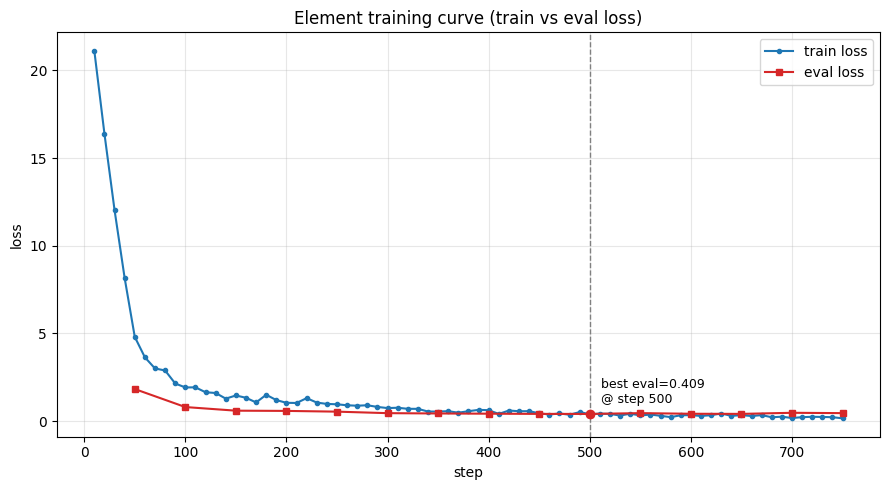

final train loss : 0.158
best  eval  loss : 0.409 @ step 500
final eval  loss : 0.456
=> Overfitting likely: train << eval (gap 0.30), eval rose after best, best is before the end.


In [13]:
# ── 학습 곡선: train_loss vs eval_loss (과적합 점검) ──────────────
# 학습 직후 실행하세요. train은 계속 내려가는데 eval이 정체/상승하면 과적합 신호입니다.
# trainer가 메모리에 있으면 그 로그를, 없으면(커널 재시작) 최신 체크포인트의 로그를 사용합니다.
import os, glob, json
from pathlib import Path
import matplotlib.pyplot as plt


def load_log_history():
    """trainer.state.log_history 우선, 없으면 최신 checkpoint-*/trainer_state.json."""
    if "trainer" in globals() and getattr(trainer, "state", None) is not None:
        return trainer.state.log_history
    out = CFG["training"]["output_dir"] if "CFG" in globals() else "../checkpoints_elements"
    ckpts = sorted(glob.glob(os.path.join(out, "checkpoint-*")),
                   key=lambda p: int(p.split("-")[-1]))
    if not ckpts:
        raise FileNotFoundError(f"No log history (trainer 없음, {out}에 checkpoint도 없음).")
    state = json.load(open(os.path.join(ckpts[-1], "trainer_state.json"), encoding="utf-8"))
    return state.get("log_history", [])


log   = load_log_history()
train = [(e["step"], e["loss"])      for e in log if "loss" in e and "eval_loss" not in e]
evals = [(e["step"], e["eval_loss"]) for e in log if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(9, 5))
if train:
    ax.plot(*zip(*train), "o-", color="tab:blue", markersize=3, label="train loss")
if evals:
    ax.plot(*zip(*evals), "s-", color="tab:red", markersize=4, label="eval loss")
    best_step, best_eval = min(evals, key=lambda x: x[1])
    ax.axvline(best_step, ls="--", color="gray", lw=1)
    ax.scatter([best_step], [best_eval], color="tab:red", zorder=5)
    ax.annotate(f"best eval={best_eval:.3f}\n@ step {best_step}", (best_step, best_eval),
                textcoords="offset points", xytext=(8, 8), fontsize=9)
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title("Element training curve (train vs eval loss)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

OUT = Path("output") / "loss_curve_elements.png"
OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT, dpi=150)
print(f"Saved loss curve -> {OUT.resolve()}")
plt.show()

# ── 과적합 간단 진단 ─────────────────────────────────────────────
if train and evals:
    final_train          = train[-1][1]
    best_step, best_eval = min(evals, key=lambda x: x[1])
    final_eval           = evals[-1][1]
    last_step            = evals[-1][0]
    print(f"final train loss : {final_train:.3f}")
    print(f"best  eval  loss : {best_eval:.3f} @ step {best_step}")
    print(f"final eval  loss : {final_eval:.3f}")
    gap   = final_eval - final_train
    rose  = final_eval > best_eval + 1e-3
    early = best_step < last_step
    if gap > 0.2 and (rose or early):
        print(f"=> Overfitting likely: train << eval (gap {gap:.2f})"
              f"{', eval rose after best' if rose else ''}"
              f"{', best is before the end' if early else ''}.")
    else:
        print(f"=> Weak overfitting signal (gap {gap:.2f}).")

## Step 5 – 평가 (Evaluation)

**Leaf-Match Score**: 예측 JSON과 정답 JSON의 모든 리프(leaf) 값을 비교하여 일치율을 계산합니다.  
(완전한 TED 구현을 원하면 `zss` 패키지를 사용하세요)

> 🔹 **평가 유틸리티 정의** — 구조화 완전일치 및 field-level 지표 헬퍼.

In [14]:
# ── Step 5a: 평가 유틸리티 (논문식 field-level 지표) ─────────────
# parse_to_schema / token2json / decode_tree / field_prf1 / _flatten 은 공통 헬퍼 셀에 정의됨.
def structured_exact(pred, gt):
    """구조화 dict 완전일치(공백무시)."""
    return _flatten(pred) == _flatten(gt)
print("평가 유틸리티(field-level P/R/F1) 준비 ✓")

평가 유틸리티(field-level P/R/F1) 준비 ✓


> 🔹 체크포인트로 validation 전체를 추론해 field-level P/R/F1 산출.

In [15]:
# ── Step 5b: Validation 평가 (flat 예측 → 정규식 구조화 → field-level P/R/F1 + 글자유사도) ──
from collections import defaultdict
CHECKPOINT = os.path.join(CFG["training"]["output_dir"], "final")
MAX_NEW    = CFG["model"]["max_length"]
if os.path.isdir(CHECKPOINT):
    eval_processor = DonutProcessor.from_pretrained(CHECKPOINT, backend="pil")
    eval_model     = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT).to(device)
else:
    print(f"체크포인트 없음: {CHECKPOINT} — 현재 model 사용")
    eval_model, eval_processor = model, processor
eval_model.eval()
# [복구] tie=False 로 저장된 체크포인트는 lm_head 가 빠져 랜덤 → 강제 재-tie 로 임베딩에 묶어 복원.
#   (빌드에서 tie 줄 제거 + 재학습하면 근본 해결; 이 블록은 옛 체크포인트 즉시 검증용이자 무해한 안전장치)
eval_model.config.tie_word_embeddings = True
eval_model.decoder.config.tie_word_embeddings = True
eval_model.tie_weights()
task_prompt = CFG["data"]["task_prompt"]
dec_ids = eval_processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

def _to_value(seq):
    """모델 출력 → 통짜 값 텍스트(flat). <s_value>…</s_value> 우선, 없으면 잔여."""
    for t in (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
              eval_processor.tokenizer.bos_token, task_prompt):
        if t: seq = seq.replace(t, "")
    parsed = token2json(seq.strip())
    if isinstance(parsed, dict):
        return str(parsed.get("value", next(iter(parsed.values()), "")))
    return str(parsed)

val_root = CFG["data"]["local_val_dir"]; pairs = []
for ip in sorted((Path(val_root) / "images").glob("*.png")):
    lp = Path(val_root) / "labels" / (ip.stem + ".json")
    if lp.exists():
        gt = json.load(open(lp, encoding="utf-8")); c = next(iter(gt)); pairs.append((ip, c, str(gt[c])))

P=[];R=[];F=[];H=[];EX=[];CS=[]; per = defaultdict(lambda: {"n":0,"f":0.0,"ex":0,"cs":0.0})
with torch.inference_mode():
    for ip, c, v in tqdm(pairs, desc="Evaluating"):
        pv = eval_processor(Image.open(ip).convert("RGB"), return_tensors="pt").pixel_values.to(device)
        out = eval_model.generate(pv, decoder_input_ids=dec_ids, max_length=MAX_NEW,
            pad_token_id=eval_processor.tokenizer.pad_token_id, eos_token_id=eval_processor.tokenizer.eos_token_id,
            use_cache=True, no_repeat_ngram_size=3, repetition_penalty=1.5)
        pred_val = _to_value(eval_processor.batch_decode(out, skip_special_tokens=False)[0])
        pred = parse_to_schema(c, _norm_value(pred_val))   # 공백 정규화 후 구조화
        gts  = parse_to_schema(c, v)
        p, r, f, h = field_prf1(pred, gts); ex = (_flatten(pred) == _flatten(gts))
        cs = value_charsim(pred_val, v)
        P.append(p); R.append(r); F.append(f); H.append(h); EX.append(ex); CS.append(cs)
        d = per[c]; d["n"] += 1; d["f"] += f; d["ex"] += ex; d["cs"] += cs
n = len(F) or 1
print(f"\n평가 완료 — {len(F)} 샘플")
print(f"Field-level F1(논문식): {sum(F)/n:.3f}  (P {sum(P)/n:.3f} / R {sum(R)/n:.3f} / Halluc {sum(H)/n:.3f})")
print(f"값 글자유사도(charsim): {sum(CS)/n:.3f}   |   구조 완전일치(exact): {sum(EX)/n*100:.1f}%")
for c in sorted(per, key=lambda c: -per[c]["n"]):
    d = per[c]; print(f"  {c:<20} F1 {d['f']/d['n']:.3f} / charsim {d['cs']/d['n']:.3f} / exact {d['ex']/d['n']*100:5.1f}%  (n={d['n']})")


Evaluating: 100%|██████████| 197/197 [00:04<00:00, 43.92it/s]


평가 완료 — 197 샘플
Field-level F1(논문식): 0.520  (P 0.519 / R 0.520 / Halluc 0.481)
값 글자유사도(charsim): 0.825   |   구조 완전일치(exact): 47.7%
  Dimension            F1 0.532 / charsim 0.835 / exact  51.4%  (n=140)
  Surface_Roughness    F1 0.619 / charsim 0.844 / exact  61.9%  (n=21)
  GD&T_FCF             F1 0.369 / charsim 0.781 / exact   0.0%  (n=16)
  Datum                F1 0.636 / charsim 0.770 / exact  63.6%  (n=11)
  Hole_Callout         F1 0.222 / charsim 0.772 / exact  22.2%  (n=9)


## Step 6 – 추론 (Inference)

이미지 파일 한 장을 넣으면 JSON 결과를 반환합니다.

> 🔹 학습된 체크포인트 로드 후 단일 이미지 구조화 추론 predict 함수 정의.

Loading weights: 100%|██████████| 483/483 [00:00<00:00, 21755.48it/s]


추론 모델 로드 완료 → ../checkpoints_elements/final
입력: ../data/processed_elements/val/images/1375_t45_f001_s01_Dime.png
읽은 값(raw): '-Ø .750 +�0 .00'
추론(구조화 JSON): {
  "Dimension": {
    "nominalValue": "-Ø.750 +�0.00"
  }
}


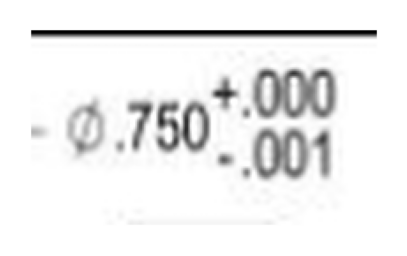

In [16]:
# ── Step 6: 단일 이미지 추론 (flat 읽기 → 타입별 정규식 구조화) ──
import os, glob, json
device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR = os.path.join(CFG["training"]["output_dir"], "final")
assert os.path.isdir(CKPT_DIR), f"체크포인트 없음: {CKPT_DIR} — 먼저 Step 4 학습을 실행하세요."
eval_processor = DonutProcessor.from_pretrained(CKPT_DIR, backend="pil")
eval_model     = VisionEncoderDecoderModel.from_pretrained(CKPT_DIR).to(device).eval()
print(f"추론 모델 로드 완료 → {CKPT_DIR}")
# [복구] tie=False 로 저장된 체크포인트는 lm_head 가 빠져 랜덤 → 강제 재-tie 로 임베딩에 묶어 복원.
#   (빌드에서 tie 줄 제거 + 재학습하면 근본 해결; 이 블록은 옛 체크포인트 즉시 검증용이자 무해한 안전장치)
eval_model.config.tie_word_embeddings = True
eval_model.decoder.config.tie_word_embeddings = True
eval_model.tie_weights()

@torch.inference_mode()
def read_value(image_path: str, task: str = None) -> str:
    """element 크롭 → 통짜 값 텍스트(모델은 OCR 만 담당)."""
    task = task or CFG["data"]["task_prompt"]
    pv = eval_processor(Image.open(image_path).convert("RGB"), return_tensors="pt").pixel_values.to(device)
    di = eval_processor.tokenizer(task, add_special_tokens=False, return_tensors="pt").input_ids.to(device)
    out = eval_model.generate(pv, decoder_input_ids=di, max_length=CFG["model"]["max_length"],
        pad_token_id=eval_processor.tokenizer.pad_token_id, eos_token_id=eval_processor.tokenizer.eos_token_id,
        use_cache=True, no_repeat_ngram_size=3, repetition_penalty=1.5)
    seq = eval_processor.batch_decode(out, skip_special_tokens=False)[0]
    for t in (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
              eval_processor.tokenizer.bos_token, task):
        if t: seq = seq.replace(t, "")
    parsed = token2json(seq.strip())
    if isinstance(parsed, dict):
        return str(parsed.get("value", next(iter(parsed.values()), "")))
    return str(parsed)

def predict(image_path: str, elem_type: str = None, task: str = None) -> dict:
    """크롭 → 구조화 dict. elem_type(YOLO 제공)면 정규식으로 {type:{fields}} 구조화."""
    val = _norm_value(read_value(image_path, task))
    if elem_type:
        return {elem_type: parse_to_schema(elem_type, val)}
    return {"value": val}

# ── 데모: 검증셋 첫 이미지 ───────────────────────────────────────
val_dir = os.path.join(CFG["data"]["local_val_dir"], "images")
cands   = sorted(glob.glob(os.path.join(val_dir, "*"))) or sorted(glob.glob("../data/elements/images/*"))
p = cands[0]
lp = os.path.join(CFG["data"]["local_val_dir"], "labels", os.path.splitext(os.path.basename(p))[0] + ".json")
et = next(iter(json.load(open(lp, encoding="utf-8")).keys())) if os.path.exists(lp) else None
print(f"입력: {p}")
print(f"읽은 값(raw): {read_value(p)!r}")
print("추론(구조화 JSON):", json.dumps(predict(p, et), ensure_ascii=False, indent=2))
fig, ax = plt.subplots(figsize=(5, 4)); ax.imshow(Image.open(p).convert("RGB")); ax.axis("off"); plt.show()


## 추론 결과를 최종 JSON 으로 조립

모델은 **통짜 값 텍스트**를 읽고(`read_value`), YOLO 가 준 **type** 별로 `parse_to_schema` 정규식이
**필드 dict**(`{quantity, nominalValue, upperLimit, lowerLimit}` 등)로 구조화 → `{type: {fields}}` 로 조립합니다.
(기호는 실제 토큰이라 별도 글리프 복원 불필요.)

> 논문 Fig.5 의 image–JSON 쌍과 동일한 **구조화 출력 형식**(단, 생성은 flat → 사후 구조화).

> 🔹 검증셋 한 장을 추론하고 YOLO 타입과 묶어 최종 JSON 으로 조립.

In [17]:
# ── 추론 결과 → 최종 JSON 조립 (구조화) ──────────────
# 구조화 모델은 필드 dict 를 출력 → YOLO type 과 묶어 {type: {fields}} 로 조립.
import json, glob, os
_cands = (sorted(glob.glob(os.path.join(CFG["data"]["local_val_dir"], "images", "*")))
          or sorted(glob.glob("../data/elements/images/*")))
if _cands:
    _p  = _cands[0]
    _lp = os.path.join(CFG["data"]["local_val_dir"], "labels", os.path.splitext(os.path.basename(_p))[0] + ".json")
    _et = next(iter(json.load(open(_lp, encoding="utf-8")).keys())) if os.path.exists(_lp) else "value"
    print(_p)
    print(json.dumps(predict(_p, _et), indent=2, ensure_ascii=False))
else:
    print("element 크롭이 아직 없습니다 — 데이터 준비/학습 후 실행하세요")

../data/processed_elements/val/images/1375_t45_f001_s01_Dime.png
{
  "Dimension": {
    "nominalValue": "-Ø.750 +�0.00"
  }
}


### (데모) 구조화 추론 ↔ GT 비교

검증셋 몇 개를 구조화로 추론해, `parse_to_schema` 로 만든 GT 구조와 **필드 단위로** 비교합니다.

> 🔹 검증셋 여러 장을 구조화 추론해 GT 와 비교(데모).

In [18]:
# ── (데모) 검증셋 몇 개: 읽은 값 → 구조화 → GT 비교 ──────────────
import glob, os, json
_imgs = sorted(glob.glob(os.path.join(CFG["data"]["local_val_dir"], "images", "*")))[:8]
for _p in _imgs:
    _lp = os.path.join(CFG["data"]["local_val_dir"], "labels", os.path.splitext(os.path.basename(_p))[0] + ".json")
    _gt = json.load(open(_lp, encoding="utf-8")) if os.path.exists(_lp) else {}
    _c  = next(iter(_gt.keys()), "value"); _v = str(next(iter(_gt.values()), ""))
    _raw  = read_value(_p)                       # 통짜 읽기
    _pred = parse_to_schema(_c, _norm_value(_raw))   # 공백 정규화 후 구조화
    _gts  = parse_to_schema(_c, _v)
    _ok   = _flatten(_pred) == _flatten(_gts)
    print(f"[{'O' if _ok else 'X'}] {_c:<16} GT={_gts}  pred={_pred}  raw={_raw!r}")


[X] Dimension        GT={'upperLimit': '+000', 'lowerLimit': '-001', 'nominalValue': '-Ø.750'}  pred={'nominalValue': '-Ø.750 +�0.00'}  raw='-Ø .750 +�0 .00'
[X] Datum            GT={'datum': '⊥ A'}  pred={'datum': 'A'}  raw='A'
[O] Dimension        GT={'nominalValue': '30°'}  pred={'nominalValue': '30°'}  raw='30°'
[O] Dimension        GT={'nominalValue': '25'}  pred={'nominalValue': '25'}  raw='25'
[O] Datum            GT={'datum': 'A'}  pred={'datum': 'A'}  raw='A'
[O] Dimension        GT={'upperLimit': '+0.1', 'lowerLimit': '-0.1', 'nominalValue': '90'}  pred={'upperLimit': '+0.1', 'lowerLimit': '-0.1', 'nominalValue': '90'}  raw='90±0 .1'
[X] Surface_Roughness GT={'roughness': '80'}  pred={'roughness': '8°'}  raw='8°'
[O] Dimension        GT={'nominalValue': '12'}  pred={'nominalValue': '12'}  raw='12'


---
## Element 파인튜닝 체크리스트 & 트러블슈팅

### 실행 순서 요약
1. **Step 0 ~ 공통 import** 실행
2. **Step 1 (CFG)** — 그대로 실행 (element 용으로 이미 설정됨)
3. **라벨 점검** — 빈 값 비율 확인, 가능한 한 라벨을 채운다
4. **데이터 분리** — `data/processed_elements/{train,val}` 생성 (`cvat_to_donut.py` → split 셀)
5. **Step 2 ~ 3** — 모델/데이터셋 로드 (`<s_element>` + 타입 토큰 자동 추가 확인)
6. **Step 4** — 학습 (`checkpoints_elements/`에 저장)
7. **Step 5 ~ 6** — 평가 및 추론

### 자주 겪는 문제
| 증상 | 원인 | 해결 |
|------|------|------|
| 출력이 빈 값/엉뚱한 값 | 라벨에 빈 값이 많음, 데이터 부족 | 라벨 채우기, 데이터 추가, 에폭↑ |
| `eval_loss`가 다시 증가 | 과적합 (데이터 적을 때 흔함) | `EarlyStoppingCallback`이 조기 종료 + `load_best_model_at_end`가 best 복원 / 데이터↑ |
| 작은 글자 인식 실패 | 입력 해상도 부족 | `image_size`를 키움 (VRAM↑) |
| CUDA out of memory | 배치/해상도 과다 | `batch_size=1`, `gradient_accumulation_steps`↑ |
| 생성이 중간에 잘림 | `max_length` 부족 | `max_length`↑ (element 값은 짧아 128 로 충분) |

### 데이터 양에 따른 권장 설정
- ~50장: `num_epochs 100`, 과적합 주의, 결과는 PoC 수준
- 수백 장: `num_epochs 50~80`
- 수천 장: `num_epochs 10~30`

> 핵심은 **라벨 품질과 스키마 일관성**입니다. 모든 라벨 JSON의 키 구조를 동일하게 유지하세요.
